In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch
import torch.nn as nn
from torch.func import vmap, grad, functional_call
from torchvision import datasets, transforms
from dp_accounting import dp_event
from dp_accounting.rdp import rdp_privacy_accountant as rdp_acct

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

'''
 “I ACCEPT THE HONOUR CODE
 LLMs were used in debugging dp_accounting library, framing the training loops and plotting code and final removal of redundant code. All other code is my own work.

Using device: mps


## Question 1: Batch Size vs. Signal-to-Noise Ratio

In [2]:
n      = 60000
delta  = n ** -1.1
T      = 2400

epsilons    = [2, 8, 32, 128]
batch_sizes = [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384, 32768]

In [3]:
def find_sigma(target_eps, delta, steps, sample_rate, lo=0.01, hi=1000.0, tol=1e-6):
    for _ in range(100):
        mid = (lo + hi) / 2
        acct = rdp_acct.RdpAccountant()
        acct.compose(
            dp_event.PoissonSampledDpEvent(sample_rate, dp_event.GaussianDpEvent(mid)),
            count=steps
        )
        if acct.get_epsilon(delta) <= target_eps:
            hi = mid
        else:
            lo = mid
        if hi - lo < tol:
            break
    return hi

In [ ]:
q1_ratios = {}

for eps in epsilons:
    ratios = []
    for m in batch_sizes:
        sigma = find_sigma(eps, delta, T, m / n)
        ratios.append(sigma / m)
        print(f'  eps={eps:3d}, m={m:6d}, sigma={sigma:.4f}, sigma/m={sigma/m:.6f}')
    q1_ratios[eps] = ratios

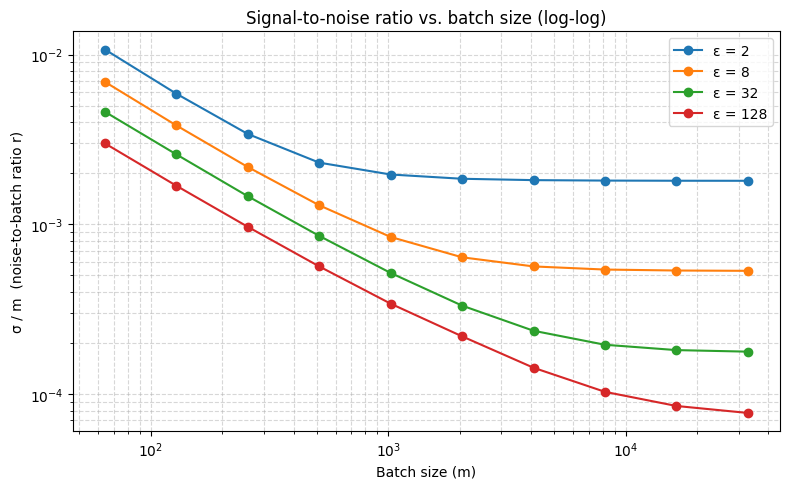

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for eps in epsilons:
    ax.loglog(batch_sizes, q1_ratios[eps], marker='o', label=f'ε = {eps}')

ax.set_xlabel('Batch size (m)')
ax.set_ylabel('σ / m  (noise-to-batch ratio r)')
ax.set_title('Signal-to-noise ratio vs. batch size (log-log)')
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [6]:
def slope_and_knee(xs, ys):
    lx = np.log(np.array(xs, dtype=float))
    ly = np.log(np.array(ys, dtype=float))
    slopes = np.diff(ly) / np.diff(lx)
    knee   = int(np.argmax(np.diff(slopes))) + 1
    return np.mean(slopes[:knee]), xs[knee + 1]

print('Q1 / Q2 answers:')
for eps in epsilons:
    slope, sat_m = slope_and_knee(batch_sizes, q1_ratios[eps])
    print(f'  eps={eps:3d} | log-log slope = {slope:.3f} | saturation at m ≈ {sat_m}')

Q1 / Q2 answers:
  eps=  2 | log-log slope = -0.738 | saturation at m ≈ 1024
  eps=  8 | log-log slope = -0.759 | saturation at m ≈ 2048
  eps= 32 | log-log slope = -0.714 | saturation at m ≈ 8192
  eps=128 | log-log slope = -0.695 | saturation at m ≈ 16384


## Question 2: DP-SGD Implementation

In [7]:
def per_example_grads(model, loss_fn, batch, targets):
    params  = dict(model.named_parameters())
    buffers = dict(model.named_buffers())

    def single_loss(params, buffers, x, y):
        out = functional_call(model, (params, buffers), x.unsqueeze(0))
        return loss_fn(out, y.unsqueeze(0))

    return vmap(grad(single_loss), in_dims=(None, None, 0, 0))(params, buffers, batch, targets)

In [8]:
def grad_norms(grads):
    b = next(iter(grads.values())).shape[0]
    sq_sum = torch.zeros(b, device=device)
    for g in grads.values():
        sq_sum += g.flatten(start_dim=1).pow(2).sum(dim=1)
    return sq_sum.sqrt()

In [9]:
def clip_grads(grads, C):
    norms = grad_norms(grads)
    clipped = {}
    for name, g in grads.items():
        scale = torch.clamp(C / (norms + 1e-6), max=1.0)
        for _ in range(g.dim() - 1):
            scale = scale.unsqueeze(-1)
        clipped[name] = g * scale
    return clipped

In [10]:
def dpsgd_step(model, loss_fn, batch, targets, C, sigma, eta):
    b = batch.shape[0]
    grads = per_example_grads(model, loss_fn, batch, targets)
    grads = clip_grads(grads, C)
    with torch.no_grad():
        for name, p in model.named_parameters():
            g_sum = grads[name].sum(dim=0)
            noise = torch.randn_like(g_sum) * sigma * C
            p.data -= eta * (g_sum + noise) / b

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_data = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST('./data', train=False, download=True, transform=transform)

# Q2 hyperparameters
n      = len(train_data)   # 60000
C      = 1.0
T      = 2400
eps_q2 = 8.0
delta  = n ** -1.1
m_q2   = 100

sigma_q2 = find_sigma(eps_q2, delta, T, m_q2 / n)
print(f'eps={eps_q2}, m={m_q2}, sigma={sigma_q2:.4f}, delta={delta:.2e}')

eps=8.0, m=100, sigma=0.4715, delta=5.55e-06


In [12]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        return self.fc2(torch.relu(self.fc1(x)))

In [13]:
def evaluate(model):
    model.eval()
    correct = 0
    loader  = torch.utils.data.DataLoader(test_data, batch_size=512, shuffle=False)
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correct += (model(x).argmax(dim=1) == y).sum().item()
    return correct / len(test_data)


def train_dpsgd(eta, T=2400, batch_sz=100, sigma=None):
    loader  = torch.utils.data.DataLoader(train_data, batch_size=batch_sz, shuffle=True)
    model   = MLP().to(device)
    loss_fn = nn.CrossEntropyLoss()
    step = 0
    while step < T:
        for x, y in loader:
            if step >= T:
                break
            x, y = x.to(device), y.to(device)
            dpsgd_step(model, loss_fn, x, y, C, sigma, eta)
            step += 1
    return evaluate(model)

In [15]:
lrs = [0.01, 0.1, 1.0, 10.0]
accs_q2 = {}

print(f'Grid search: eps={eps_q2}, m={m_q2}, sigma={sigma_q2:.4f}')
for eta in lrs:
    acc = train_dpsgd(eta, T=T, batch_sz=m_q2, sigma=sigma_q2)
    accs_q2[eta] = acc
    print(f'  eta={eta:5.2f}, test acc = {acc:.4f}')

Grid search: eps=8.0, m=100, sigma=0.4715
  eta= 0.01, test acc = 0.8128
  eta= 0.10, test acc = 0.9090
  eta= 1.00, test acc = 0.9027
  eta=10.00, test acc = 0.8365


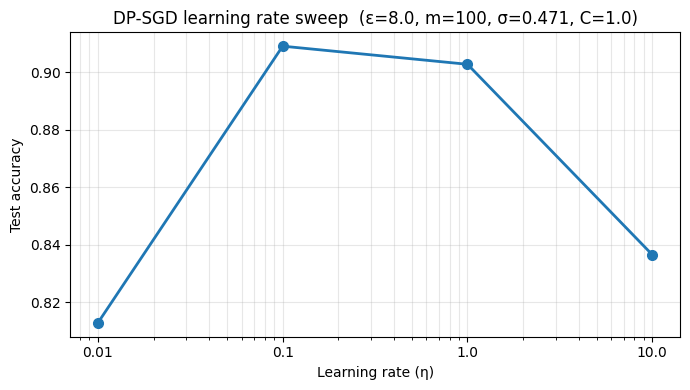

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(lrs, [accs_q2[eta] for eta in lrs], marker='o', linewidth=2, markersize=7)
plt.xscale('log')
plt.xlabel('Learning rate (η)')
plt.ylabel('Test accuracy')
plt.title(f'DP-SGD learning rate sweep  (ε={eps_q2}, m={m_q2}, σ={sigma_q2:.3f}, C={C})')
plt.xticks(lrs, [str(lr) for lr in lrs])
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Question 3: DP-SGD with Larger Batch Size

In [17]:
_, m_q3 = slope_and_knee(batch_sizes, q1_ratios[8])

sigma_q3 = find_sigma(eps_q2, delta, T, m_q3 / n)
print(f'Q3: eps={eps_q2}, m={m_q3}, sigma={sigma_q3:.4f}')

accs_q3 = {}
for eta in lrs:
    acc = train_dpsgd(eta, T=T, batch_sz=m_q3, sigma=sigma_q3)
    accs_q3[eta] = acc
    print(f'  eta={eta:5.2f} -> test acc = {acc:.4f}')

Q3: eps=8.0, m=2048, sigma=1.3102
  eta= 0.01 -> test acc = 0.8083
  eta= 0.10 -> test acc = 0.9103
  eta= 1.00 -> test acc = 0.9535
  eta=10.00 -> test acc = 0.9521


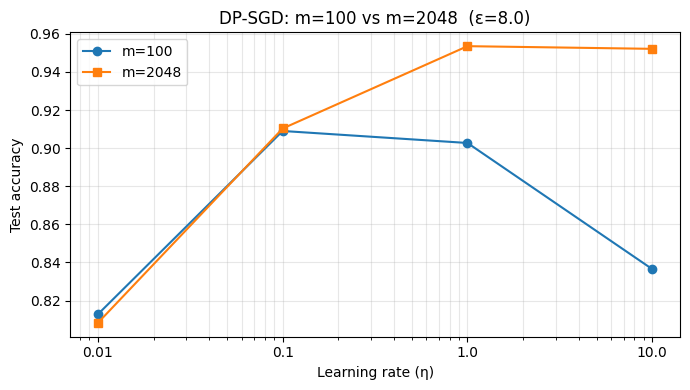

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(lrs, [accs_q2[eta] for eta in lrs], marker='o', label=f'm={m_q2}')
plt.plot(lrs, [accs_q3[eta] for eta in lrs], marker='s', label=f'm={m_q3}')
plt.xscale('log')
plt.xlabel('Learning rate (η)')
plt.ylabel('Test accuracy')
plt.title(f'DP-SGD: m={m_q2} vs m={m_q3}  (ε={eps_q2})')
plt.xticks(lrs, [str(lr) for lr in lrs])
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Question 4: Privacy-Utility Tradeoff

In [ ]:
sat_m = {eps: slope_and_knee(batch_sizes, q1_ratios[eps])[1] for eps in [2, 8, 32]}

best_fixed     = {}  
best_heuristic = {}  

for eps in [2, 8, 32]:
    d = n ** -1.1

    sigma_f = find_sigma(eps, d, T, 100 / n)
    print(f'\neps={eps}, m=100, sigma={sigma_f:.4f}')
    accs_f = []
    for eta in lrs:
        acc = train_dpsgd(eta, T=T, batch_sz=100, sigma=sigma_f)
        accs_f.append(acc)
        print(f'  eta={eta:5.2f}, test acc = {acc:.4f}')
    best_fixed[eps] = max(accs_f)

    m_h     = sat_m[eps]
    sigma_h = find_sigma(eps, d, T, m_h / n)
    print(f'eps={eps}, m={m_h}, sigma={sigma_h:.4f}')
    accs_h = []
    for eta in lrs:
        acc = train_dpsgd(eta, T=T, batch_sz=m_h, sigma=sigma_h)
        accs_h.append(acc)
        print(f'  eta={eta:5.2f}, test acc = {acc:.4f}')
    best_heuristic[eps] = max(accs_h)

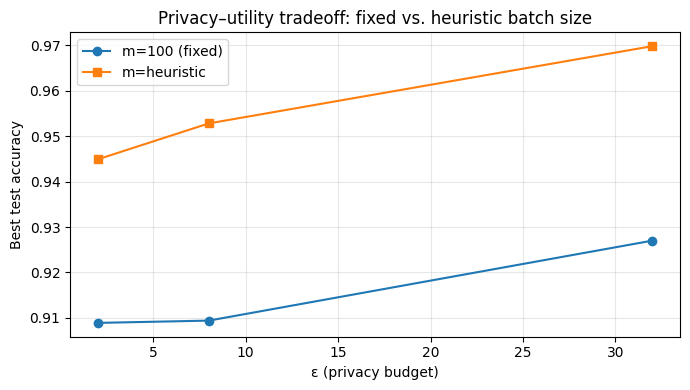

In [21]:
eps_list = [2, 8, 32]

plt.figure(figsize=(7, 4))
plt.plot(eps_list, [best_fixed[e]     for e in eps_list], marker='o', label='m=100 (fixed)')
plt.plot(eps_list, [best_heuristic[e] for e in eps_list], marker='s', label='m=heuristic')
plt.xlabel('ε (privacy budget)')
plt.ylabel('Best test accuracy')
plt.title('Privacy–utility tradeoff: fixed vs. heuristic batch size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
